In [1]:
import numpy as np
import pandas as pd
import json
np.random.seed(12345)
import matplotlib.pyplot as plt
plt.rc('figure', figsize=(10, 6))
PREVIOUS_MAX_ROWS = pd.options.display.max_rows
pd.options.display.max_columns = 20
pd.options.display.max_rows = 20
pd.options.display.max_colwidth = 80
np.set_printoptions(precision=4, suppress=True)

In [2]:
fec = pd.read_csv('data/fec/P00000001-ALL.csv', low_memory=False)
fec.info()

<class 'pandas.DataFrame'>
RangeIndex: 1001731 entries, 0 to 1001730
Data columns (total 16 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   cmte_id            1001731 non-null  str    
 1   cand_id            1001731 non-null  str    
 2   cand_nm            1001731 non-null  str    
 3   contbr_nm          1001731 non-null  str    
 4   contbr_city        1001712 non-null  str    
 5   contbr_st          1001727 non-null  str    
 6   contbr_zip         1001620 non-null  str    
 7   contbr_employer    988002 non-null   str    
 8   contbr_occupation  993301 non-null   str    
 9   contb_receipt_amt  1001731 non-null  float64
 10  contb_receipt_dt   1001731 non-null  str    
 11  receipt_desc       14166 non-null    str    
 12  memo_cd            92482 non-null    str    
 13  memo_text          97770 non-null    str    
 14  form_tp            1001731 non-null  str    
 15  file_num           1001731 non-null  int64 

In [ ]:
fec.iloc[123456]
unique_cands = fec['cand_nm'].unique()
unique_cands
unique_cands[2]


'Obama, Barack'

In [6]:
parties = {"Bachmann, Michelle": "Republican",
           "Cain, Herman": "Republican",
           "Gingrich, Newt": "Republican",
           "Huntsman, Jon": "Republican",
           "Johnson, Gary Earl": "Republican",
           "McCotter, Thaddeus G": "Republican",
           "Obama, Barack": "Democrat",
           "Paul, Ron": "Republican",
           "Pawlenty, Timothy": "Republican",
           "Perry, Rick": "Republican",
           "Roemer, Charles E. 'Buddy' III": "Republican",
           "Romney, Mitt": "Republican",
           "Santorum, Rick": "Republican"}

In [8]:
fec['cand_nm'][123456:123461]
fec['cand_nm'][123456:123461].map(parties)

123456    Democrat
123457    Democrat
123458    Democrat
123459    Democrat
123460    Democrat
Name: cand_nm, dtype: str

In [11]:
fec['party'] = fec['cand_nm'].map(parties)
fec['party'].value_counts()
(fec['contb_receipt_amt'] >0).value_counts()
fec= fec[fec['contb_receipt_amt']>0]

In [12]:
fec_mrbo=fec[fec['cand_nm'].isin(['Obama, Barack','Romney, Mitt'])]

In [15]:
fec['contbr_occupation'].value_counts()[:10]
occ_mapping ={
    'INFORMATION REQUESTED PER BEST EFFORTS': 'NOT PROVIDED',
    'INFORMATION REQUESTED':'NOT PROVIDED',
    'INFORMATION REQUESTED (BEST EFFORTS)':'NOT PROVIDED',
    'C.E.O.':'CEO'
}
def get_occ(x):
    return occ_mapping.get(x, x)
fec['contbr_occupation'] = fec['contbr_occupation'].map(get_occ)

emp_mapping ={
    'INFORMATION REQUESTED PER BEST EFFORTS': 'NOT PROVIDED',
    'INFORMATION REQUESTED':'NOT PROVIDED',
    'SELF':'SELF-EMPLOYED',
    'SELF EMPLOYED':'SELF-EMPLOYED'
}
def get_emp(x):
    return emp_mapping.get(x,x)
fec['contbr_employer'] = fec['contbr_employer'].map(get_emp)

In [16]:
by_occupation = fec.pivot_table('contb_receipt_amt',
                                index='contbr_occupation',
                                columns='party', aggfunc='sum')
over_2mm = by_occupation[by_occupation.sum(axis='columns')>2000000]
over_2mm

party,Democrat,Republican
contbr_occupation,,
ATTORNEY,11141982.97,7477194.43
CEO,2074974.79,4211040.52
CONSULTANT,2459912.71,2544725.45
ENGINEER,951525.55,1818373.70
EXECUTIVE,1355161.05,4138850.09
HOMEMAKER,4248875.80,13634275.78
INVESTOR,884133.00,2431768.92
LAWYER,3160478.87,391224.32
MANAGER,762883.22,1444532.37


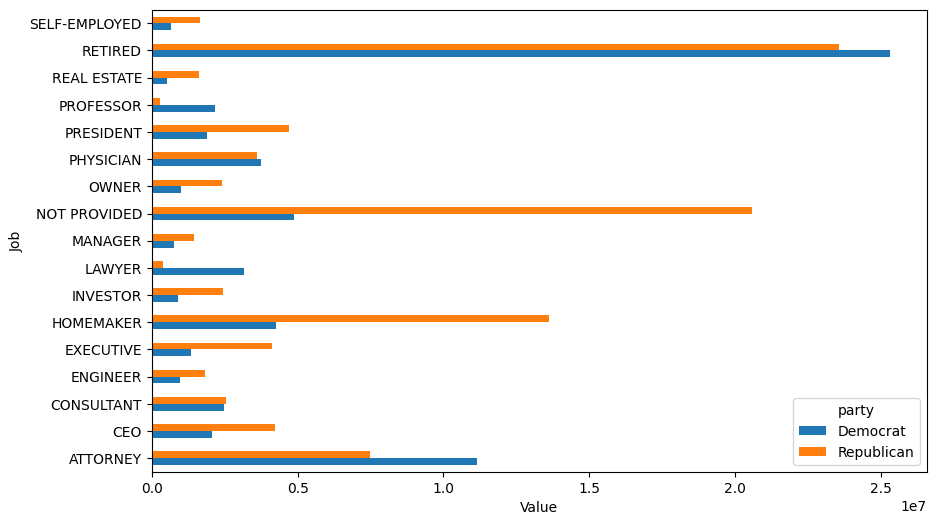

In [17]:
gfg = over_2mm.plot(kind='barh')
gfg.set(xlabel ='Value', ylabel ='Job')
plt.legend(title='party', labels=['Democrat','Republican'])

In [21]:
def get_top_amounts(group,key, n=5):
    totals = group.groupby(key)['contb_receipt_amt'].sum()
    return totals.nlargest(n)
grouped = fec_mrbo.groupby('cand_nm')
grouped.apply(get_top_amounts, 'contbr_occupation',n=7)
grouped.apply(get_top_amounts, 'contbr_employer', n=10)

cand_nm        contbr_employer                       
Obama, Barack  RETIRED                                   22694358.85
               SELF-EMPLOYED                             17080985.96
               NOT EMPLOYED                               8586308.70
               INFORMATION REQUESTED                      5053480.37
               HOMEMAKER                                  2605408.54
               SELF                                       1076531.20
               SELF EMPLOYED                               469290.00
               STUDENT                                     318831.45
               VOLUNTEER                                   257104.00
               MICROSOFT                                   215585.36
Romney, Mitt   INFORMATION REQUESTED PER BEST EFFORTS    12059527.24
               RETIRED                                   11506225.71
               HOMEMAKER                                  8147196.22
               SELF-EMPLOYED                     

In [22]:
bins = np.array([0,1,10,100,1000,10000,100000,1000000,1000000000])
labels = pd.cut(fec_mrbo['cont_receipt_amt'], bins)

KeyError: 'cont_receipt_amt'